In [158]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from omegaconf import OmegaConf

import bbrl_utils
from bbrl_utils.notebook import setup_tensorboard
from bbrl.stats import WelchTTest

import gymnasium as gym
import bbrl_gymnasium

from pmind.algorithms import DQN, DDPG, TD3
from pmind.losses import dqn_compute_critic_loss, ddqn_compute_critic_loss
from pmind.training import run_dqn, run_ddpg, run_td3
from pmind.config.loader import load_config

from pmind.replay import mix_transitions

from pmind.plot.policies import plot_rb_space_coverage, plot_policy, plot_trajectories

from pmind.plot.policies import ENV_NAMES, ALL_STATE_SPACES, ALL_STATE_NAMES, ALL_INIT_SPACES

print("Supported environments are:", ENV_NAMES)

bbrl_utils.setup()

%load_ext autoreload
%autoreload 2

Supported environments are: ('CartPoleContinuous-v1', 'Pendulum-v1', 'MountainCarContinuous-v0')
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Set up state-action space information

Is specific for each environment

In [169]:
ENV_NAME = ENV_NAMES[1]

PENDULUM_ANGLE = (ENV_NAME == "Pendulum-v1")

MODELS_DIR = f"../models/{ENV_NAME}/"
STATE_NAMES = ALL_STATE_NAMES[ENV_NAME]

print(ENV_NAME)
print("state variables", STATE_NAMES)
print("bounded by:\n",ALL_STATE_SPACES[ENV_NAME])
print("initialized in:\n", ALL_INIT_SPACES[ENV_NAME])

Pendulum-v1
state variables ['cosine', 'sine', 'angular velocity']
bounded by:
 [[-1.  1.]
 [-1.  1.]
 [-8.  8.]]
initialized in:
 [[-1  1]
 [-1  1]
 [-1  1]]


In [170]:
# since we are limited to 2D, choose two state variables
STATE_X = 0
STATE_Y = 1
if PENDULUM_ANGLE:
    print("Chosen for plot: angle and angular velocity")
else:
    print(f"Chosen for plot: {STATE_NAMES[STATE_X]} and {STATE_NAMES[STATE_Y]}")
    
POLAR_COORD = PENDULUM_ANGLE or (ENV_NAME == "CartPoleContinuous-v1" and (2 in (STATE_X, STATE_Y)) )
print(f"using { 'polar' if POLAR_COORD else 'cartesian'} coordinates")

Chosen for plot: angle and angular velocity
using polar coordinates


# Visualize replay buffers

In [ ]:
reward = -209#500
rb_unif = torch.load(MODELS_DIR + "rb-unif.pt", weights_only=False)
rb_best = torch.load(MODELS_DIR + f"rb-{reward}.pt", weights_only=False)
proportion = 0.5
rb_mixed = mix_transitions(rb_unif, rb_best, buffer_size=200_000, proportion=proportion)
replay_buffers = {
    "uniform exploration": rb_unif,
    # f"mix {proportion}": rb_mixed,
    #   "intermediate exploit policy (35)": torch.load(MODELS_DIR + "rb-35.pt", weights_only=False),
    #   "intermediate exploit policy (61)": torch.load(MODELS_DIR + "rb-61.pt", weights_only=False),
    # "exploit policy": rb_best,
    "noise 0": torch.load(MODELS_DIR + f"rb-{reward}-noise-0.0.pt", weights_only=False),
    "noise 0.5": torch.load(MODELS_DIR + f"rb-{reward}-noise-0.5.pt", weights_only=False),
    "noise 10000": torch.load(MODELS_DIR + f"rb-{reward}-noise-10000.0.pt", weights_only=False)
}

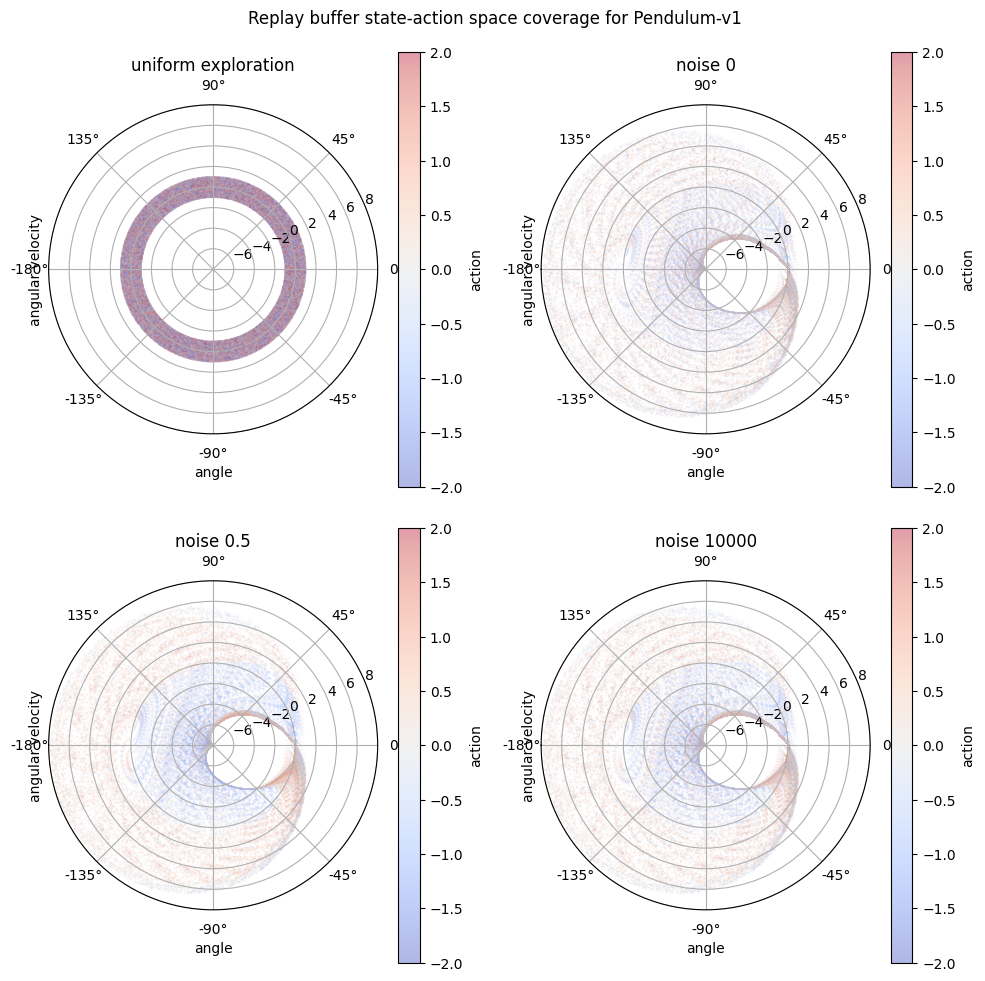

In [175]:
n_buffers = len(replay_buffers)
ncols = 2 if n_buffers > 1 else 1
nrows = int(np.ceil(n_buffers / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(10, 10),subplot_kw={"projection": "polar"} if POLAR_COORD else None)

axes = np.atleast_1d(axes).flatten()

for i, (rb_type, rb) in enumerate(replay_buffers.items()):
    plot_rb_space_coverage(
        env_name=ENV_NAME, 
        rb=rb,
        state_x=STATE_X,
        state_y=STATE_Y,
        pendulum_angle=PENDULUM_ANGLE,
        ax=axes[i]
    )
    
    axes[i].set_title(rb_type)

for ax in axes[i + 1 :]:
    fig.delaxes(ax)

plt.suptitle(f"Replay buffer state-action space coverage for {ENV_NAME}")
plt.tight_layout()
plt.show()

# Visualize learned policies

In [76]:
policies = torch.load(MODELS_DIR + "intermediate-policies.pt", weights_only=False)
policies.append(torch.load(MODELS_DIR + "best-policy.pt", weights_only=False))
policies = [item for item in policies if item is not None]

policies = dict(policies)  # expected format is dict[reward, policy]

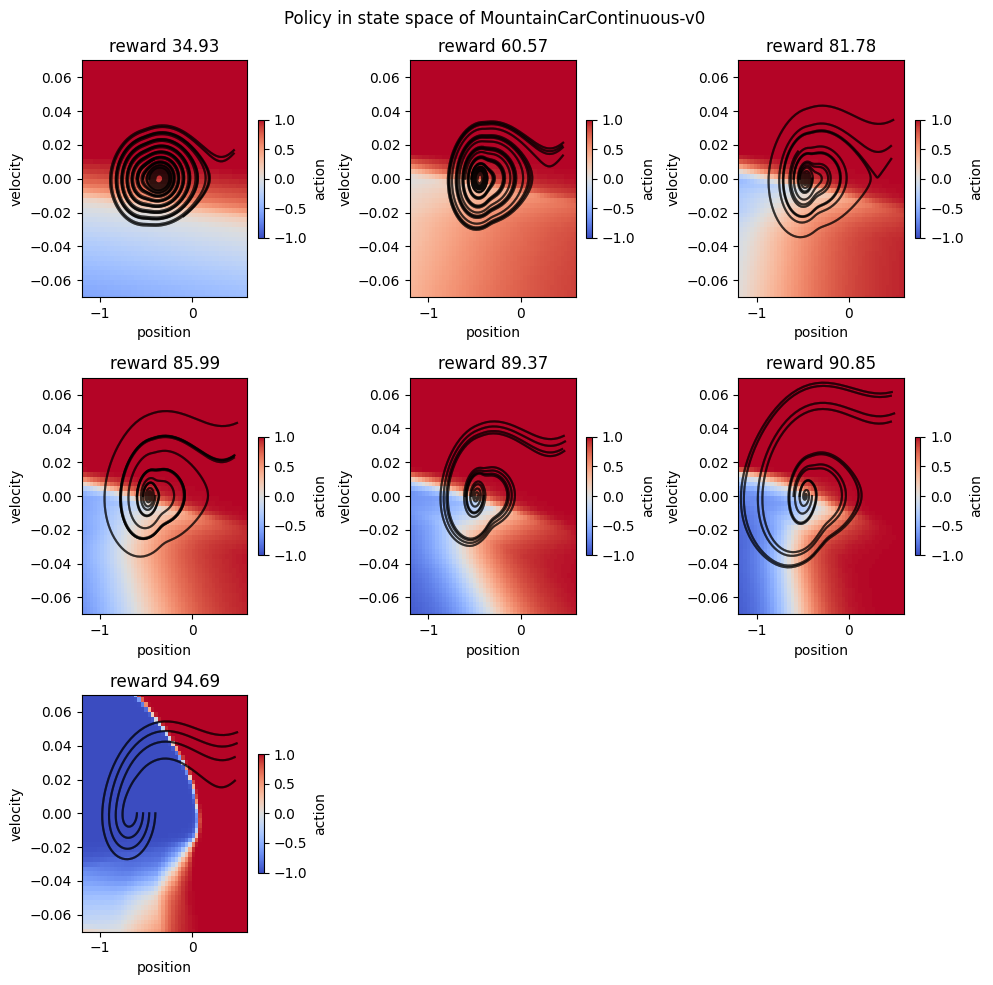

In [77]:
NB_TRAJ = 4

n_rewards = len(policies)
ncols = 3 if n_rewards > 1 else 1
nrows = int(np.ceil(n_rewards / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(10, 10),subplot_kw={"projection": "polar"} if POLAR_COORD else None)

axes = np.atleast_1d(axes).flatten()

for i, (reward, policy) in enumerate(sorted(policies.items())):
    plot_policy(
        env_name=ENV_NAME,
        policy=policy,
        state_x=STATE_X,
        state_y=STATE_Y,
        fixed_state=None, 
        ax=axes[i],
        pendulum_angle=PENDULUM_ANGLE
    )

    plot_trajectories(
        env_name=ENV_NAME,
        policy=policy,
        nb_traj=NB_TRAJ,
        state_x=STATE_X,
        state_y=STATE_Y,
        traj_length=None,
        ax=axes[i],
        pendulum_angle=PENDULUM_ANGLE
    )
    axes[i].set_title(f"reward {reward:.2f}")

for ax in axes[i + 1 :]:
    fig.delaxes(ax)

plt.suptitle(f"Policy in state space of {ENV_NAME}")
plt.tight_layout()
plt.show()

# Analyze Offline-learned policies

In [165]:
# Obtain policies and replay buffers from offline learning experiments:
RESULTS_DIR = "../results/policy_analysis-selected"
rb_composition_type = ("uniform_proportions", "noise_levels")[0]
reward = 500 #61
FNAME = f"{rb_composition_type}-{ENV_NAME}-scoring-{reward}"
test_log = torch.load(f"{RESULTS_DIR}/{FNAME}", weights_only=False)
policies = test_log["policies"]
replay_buffers = test_log["replay_buffers"]
save_rb_policy_interval = test_log["save_rb_policy_interval"]
rb_composition = test_log["rb_composition"]
rb_composition_type = test_log["type"]

rb = replay_buffers[0][0]
policies_over_time = policies[0][0]

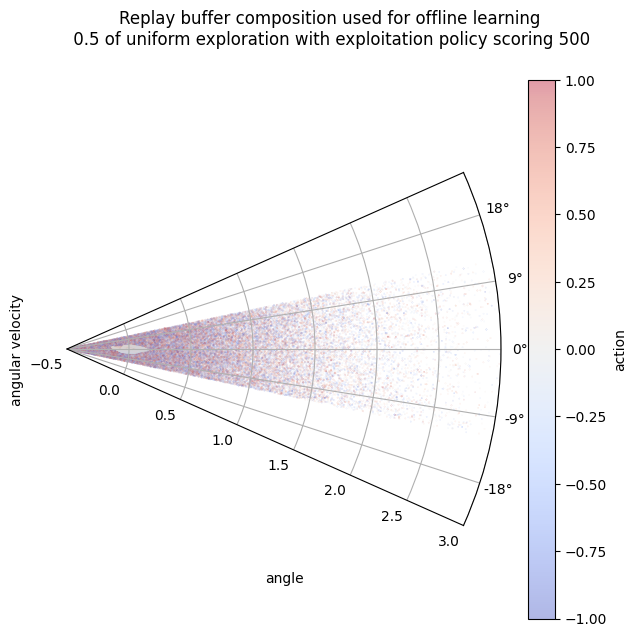

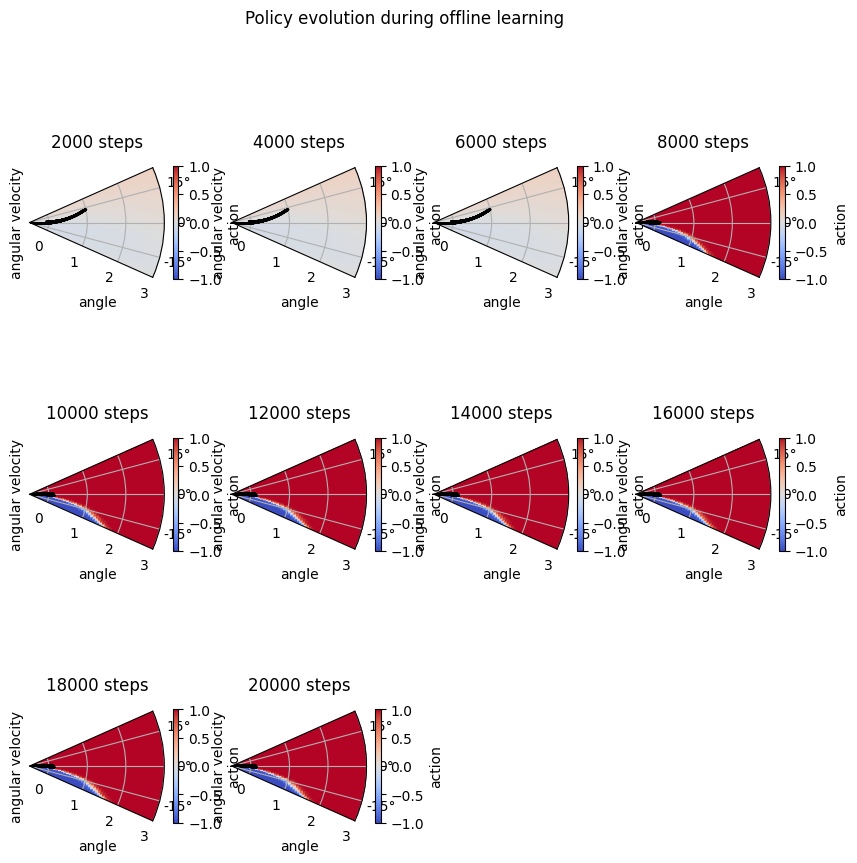

In [167]:
fig, ax = plt.subplots(figsize=(7,7),subplot_kw={"projection": "polar"} if POLAR_COORD else None)
plot_rb_space_coverage(ENV_NAME, rb, STATE_X, STATE_Y, ax=ax)
fig.suptitle(
    f"Replay buffer composition used for offline learning\n {rb_composition[0]}"
    + (
        " of uniform exploration"
        if rb_composition_type == "uniform_proportions"
        else " of action noise"
    ) + f" with exploitation policy scoring {reward}"
)
plt.show()
nrows = 3
fig, axes = plt.subplots(nrows, len(policies_over_time) // nrows + 1, figsize=(10, 10),subplot_kw={"projection": "polar"} if POLAR_COORD else None)
axes = axes.flatten()
for i, policy in enumerate(policies_over_time):
    plot_policy(ENV_NAME, policy, STATE_X, STATE_Y, ax=axes[i])
    plot_trajectories(ENV_NAME, policy, NB_TRAJ, STATE_X, STATE_Y, ax=axes[i])
    axes[i].set_title(f"{(i + 1) * save_rb_policy_interval} steps")
for ax in axes[i + 1 :]:
    fig.delaxes(ax)
fig.suptitle("Policy evolution during offline learning")
plt.show()

# SANDBOX

# Visualize learned Q-values

## TODO: get critic as well, not only actor

In [ ]:
# for ENV_NAME in ENV_NAMES:
#     ENV = gym.make(ENV_NAME)
#     STATE_SPACE = np.array([ENV.observation_space.low, ENV.observation_space.high]).T
#     print({ENV_NAME: STATE_SPACE})